# Band figures

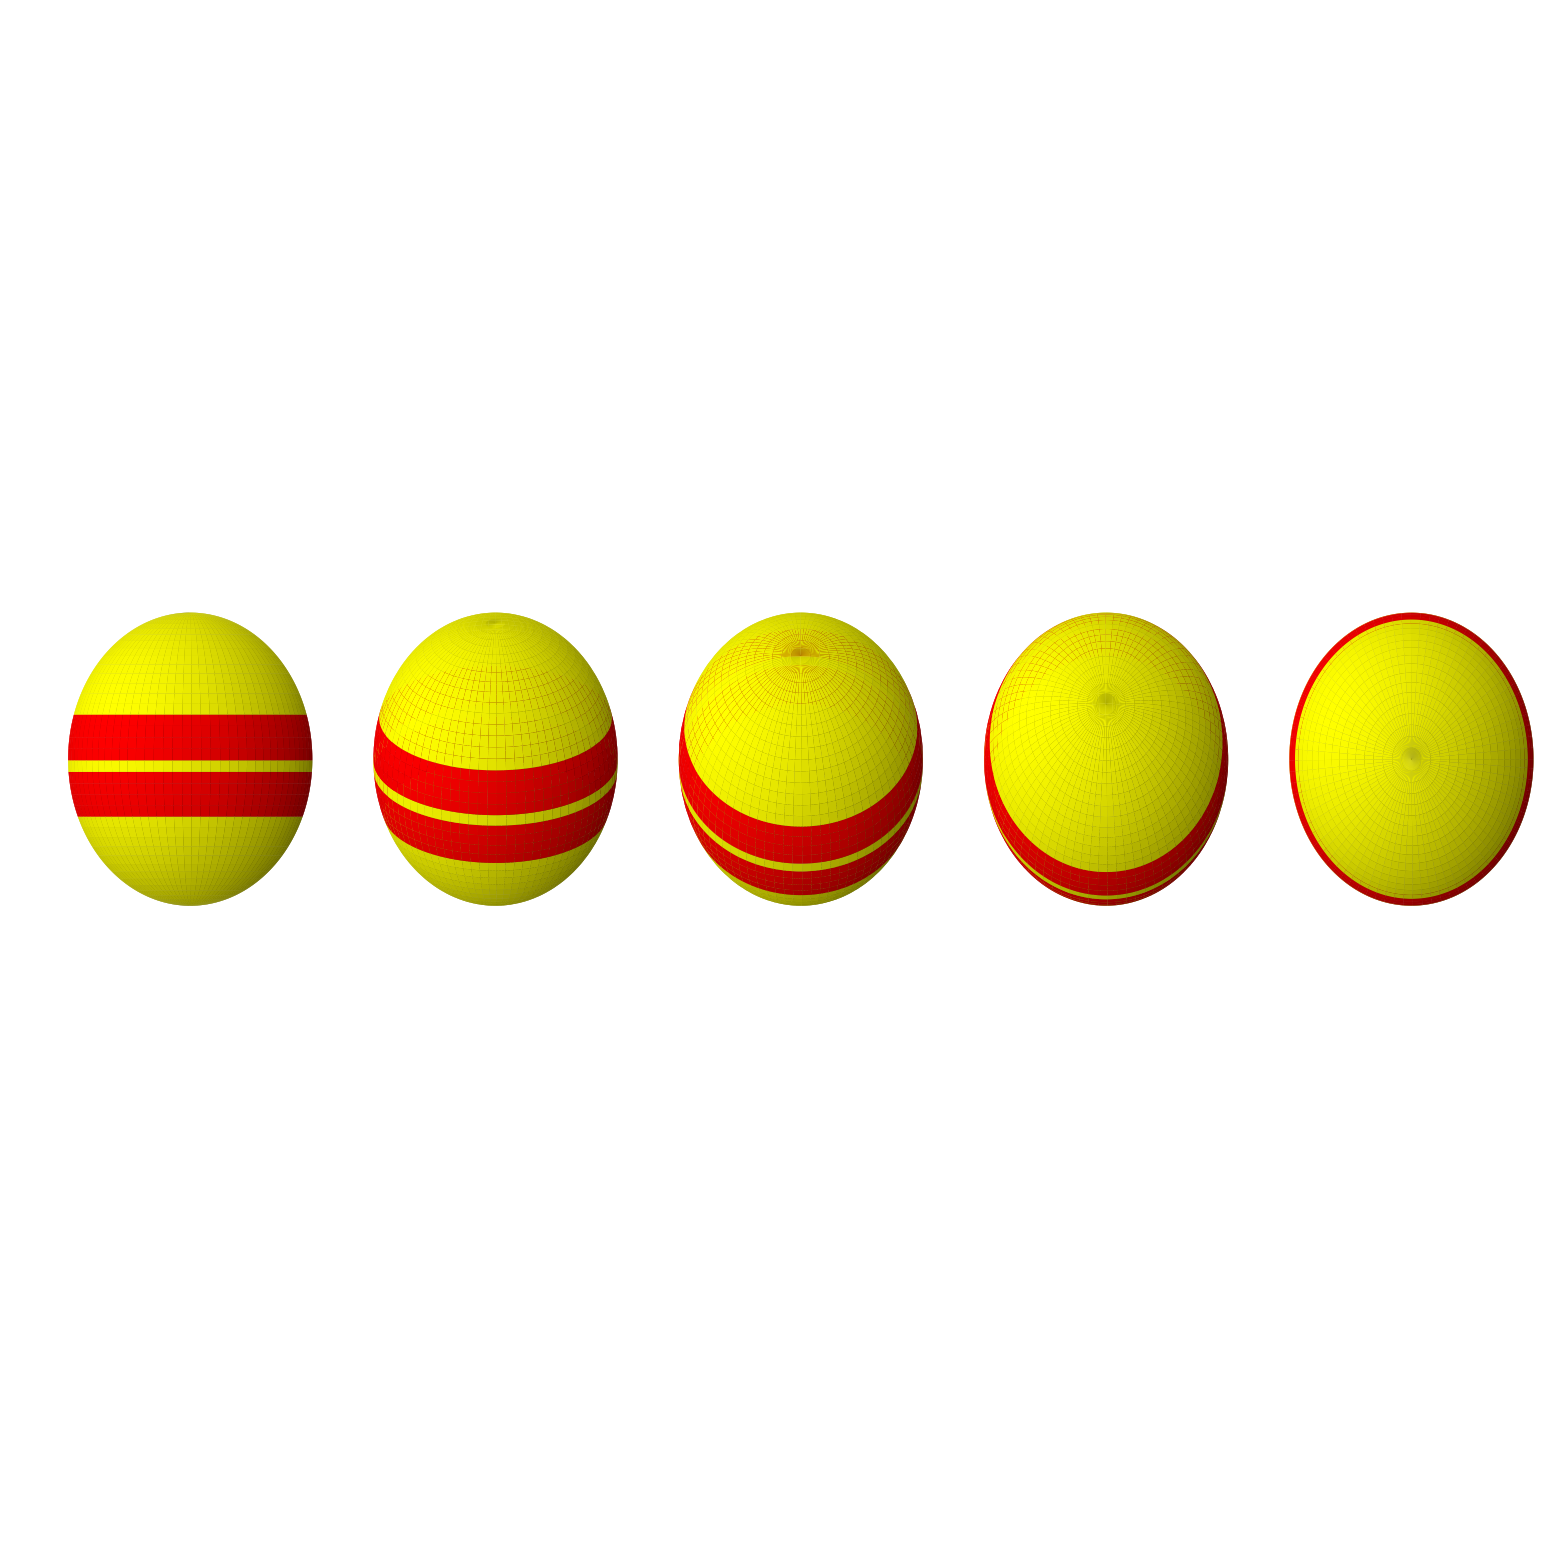

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

# ----------------------------
# parameters
# ----------------------------
r = 50  # radius

# higher resolution for smoother spheres
u, v = np.mgrid[0:2*np.pi:400j, 0:np.pi:200j]
x = r * np.cos(u) * np.sin(v)
y = r * np.sin(u) * np.sin(v)
z = r * np.cos(v)

# band colormap (yellow-red-yellow-red-yellow)
cmap_colors = ['yellow', 'red', 'yellow', 'red', 'yellow']
cmap = ListedColormap(cmap_colors)

# normalize v (colatitude) -> [0,1]
norm_v = (v - v.min()) / (v.max() - v.min())

# map near-equator region to red bands, rest to yellow (your original mapping)
color_indices = np.interp(
    norm_v,
    [0, 0.48, 0.49, 0.51, 0.52, 1],
    [0, 0.25, 0.5, 0.5, 0.75, 1]
)

# ----------------------------
# plot
# ----------------------------
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')

# your original elevations
elevations = [0, 22, 45, 68, 90]

for i, elev in enumerate(elevations):
    x_offset = i * 2.5 * r
    x_pos = x + x_offset

    # rotate around x-axis (changes y/z only)
    y_rot = y * np.cos(np.radians(elev)) - z * np.sin(np.radians(elev))
    z_rot = y * np.sin(np.radians(elev)) + z * np.cos(np.radians(elev))

    ax.plot_surface(
        x_pos, y_rot, z_rot,
        facecolors=cmap(color_indices),
        edgecolor='none',
        rstride=5, cstride=5
    )

ax.set_box_aspect([5, 1, 1])
ax.set_xlim(-r, 5 * r * 2.2)
ax.set_ylim(-r, r)
ax.set_zlim(-r, r)

# your original “orthographic-like” view
ax.view_init(elev=0, azim=-90)

ax.axis('off')
plt.savefig('globes.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


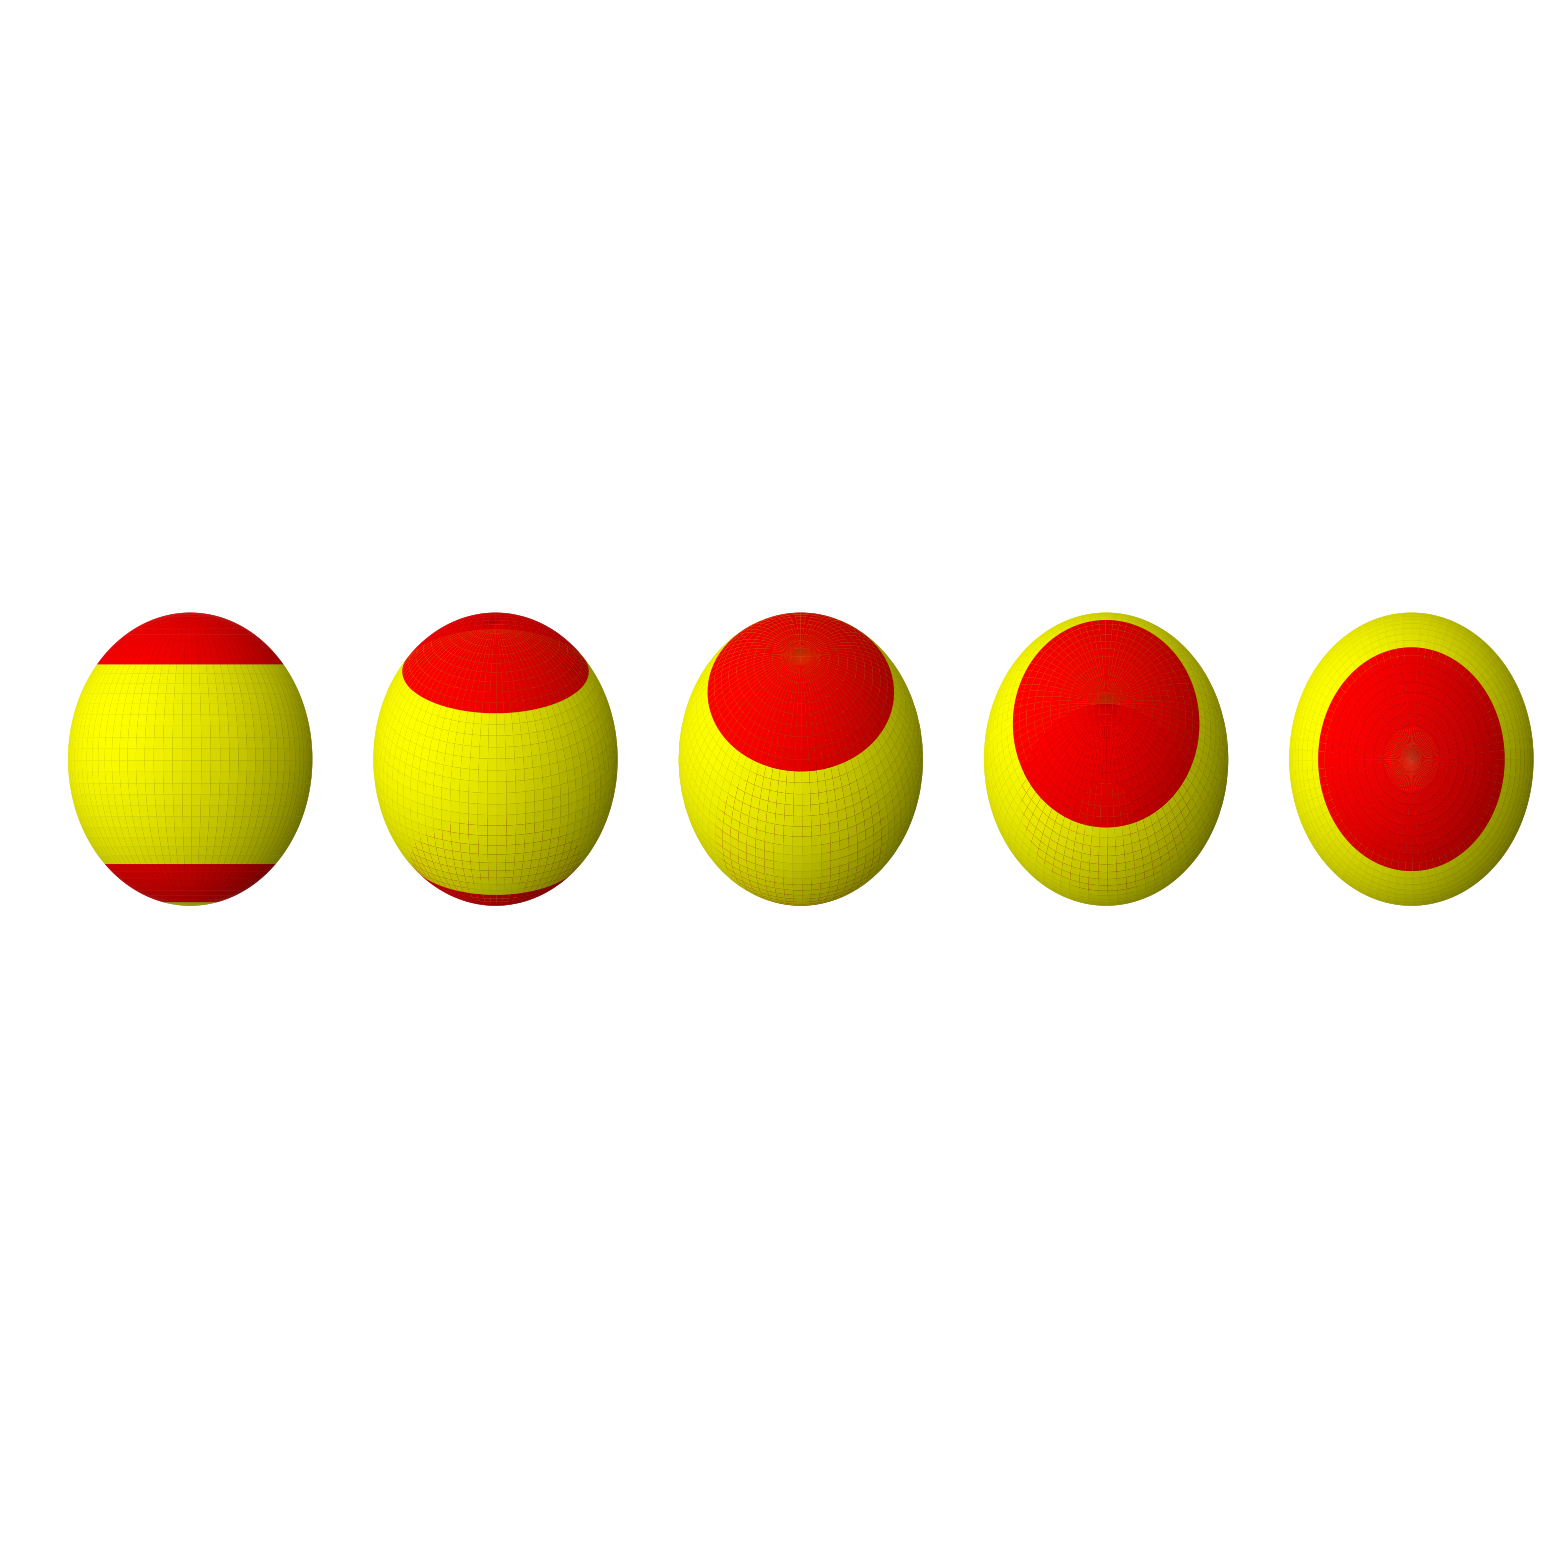

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

# ----------------------------
# parameters
# ----------------------------
r = 50  # radius

# higher resolution for smoother spheres
u, v = np.mgrid[0:2*np.pi:400j, 0:np.pi:200j]
x = r * np.cos(u) * np.sin(v)
y = r * np.sin(u) * np.sin(v)
z = r * np.cos(v)

# colormap (yellow-red-yellow-red-yellow)
cmap_colors = ['red', 'yellow', 'yellow', 'yellow', 'red']
cmap = ListedColormap(cmap_colors)

# normalize v (colatitude) -> [0,1]
norm_v = (v - v.min()) / (v.max() - v.min())

# ----------------------------
# NEW MAPPING: red at poles, yellow elsewhere
# desired: red - yellow - yellow - yellow - red
# ----------------------------
color_indices = np.interp(
    norm_v,
    [0.0, 0.1, 0.9, 1.0],   # transition widths; adjust 0.06/0.94 for thicker/thinner polar belts
    [1.0, 1.0, 0.0, 1.0]      # 1->red, 0->yellow (via your ListedColormap)
)

# ----------------------------
# plot
# ----------------------------
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')

# original elevations
elevations = [0, 22, 45, 68, 90]

for i, elev in enumerate(elevations):
    x_offset = i * 2.5 * r
    x_pos = x + x_offset

    # rotate around x-axis (changes y/z only)
    y_rot = y * np.cos(np.radians(elev)) - z * np.sin(np.radians(elev))
    z_rot = y * np.sin(np.radians(elev)) + z * np.cos(np.radians(elev))

    ax.plot_surface(
        x_pos, y_rot, z_rot,
        facecolors=cmap(color_indices),
        edgecolor='none',
        rstride=5, cstride=5
    )

ax.set_box_aspect([5, 1, 1])
ax.set_xlim(-r, 5 * r * 2.2)
ax.set_ylim(-r, r)
ax.set_zlim(-r, r)

# original “orthographic-like” view
ax.view_init(elev=0, azim=-90)

ax.axis('off')
plt.savefig('globes_polar_belts.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


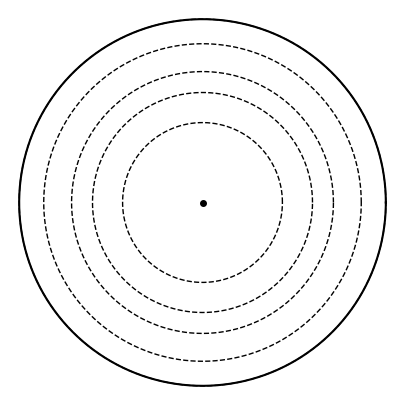

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# parameters
# ----------------------------
mu_levels = [1.0, 0.9, 0.8, 0.7, 0.5, 0.0]
npts = 1000

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(5, 5))

t = np.linspace(0, 2*np.pi, npts)

for mu in mu_levels:
    if mu == 1.0:
        # disk center
        ax.plot(0, 0, 'ko', ms=4)
    else:
        r = np.sqrt(1 - mu**2)
        x = r * np.cos(t)
        y = r * np.sin(t)
        ax.plot(x, y, 'k--', lw=1)

# outer limb (mu = 0)
ax.plot(np.cos(t), np.sin(t), 'k', lw=1.5)

# formatting
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.axis('off')

plt.savefig("mu_circles.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()
